In [ ]:
import os
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from transformers import pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub

In [ ]:
print("Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("abhi8923shriv/sentiment-analysis-dataset")
print("Download complete! File location:", path)

100%|██████████| 54.4M/54.4M [00:00<00:00, 77.0MB/s]

Extracting files...


Download complete! File location: /root/.cache/kagglehub/datasets/abhi8923shriv/sentiment-analysis-dataset/versions/9


In [ ]:
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if not csv_files:
    raise FileNotFoundError("No CSV files found in this dataset.")

data_path = os.path.join(path, csv_files[0])
try:
    df = pd.read_csv(data_path)
except UnicodeDecodeError:
    df = pd.read_csv(data_path, encoding='latin-1')

print(f"Data loaded successfully. Total rows: {len(df)}")
print("Sample columns in the dataset:", df.columns.tolist())

Data loaded successfully. Total rows: 27481
Sample columns in the dataset: ['textID', 'text', 'selected_text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']


In [ ]:
text_col = 'text'
sentiment_col = 'sentiment'

In [ ]:
# Drop missing values and sample 1,000 rows for faster testing (remove .sample() for full run)
df = df.dropna(subset=[text_col, sentiment_col]).sample(n=1000, random_state=42)

# Encode sentiment labels to numerical values (0=Negative, 1=Neutral, 2=Positive)
# Note: Adjust conditions if dataset uses different labels like 'neg', 'pos'
def encode_true_label(label):
    label = str(label).strip().lower()
    if label in ['negative', 'neg', '0']: return 0
    elif label in ['neutral', 'neu', '1']: return 1
    else: return 2

df['true_label'] = df[sentiment_col].apply(encode_true_label)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch # Added import torch

# Prepare models from Hugging Face
device = 0 if torch.cuda.is_available() else -1

print("\nLoading RoBERTa, BERTweet, and RoBERTa-large models...")
# RoBERTa model (cardiffnlp)
roberta_pipe = pipeline("text-classification", model="cardiffnlp/twitter-roberta-base-sentiment", device=device)

# BERTweet model (finiteautomata)
bertweet_model_name = "finiteautomata/bertweet-base-sentiment-analysis"
bertweet_tokenizer = AutoTokenizer.from_pretrained(bertweet_model_name)
bertweet_model = AutoModelForSequenceClassification.from_pretrained(bertweet_model_name)
bert_pipe = pipeline("text-classification", model=bertweet_model, tokenizer=bertweet_tokenizer, device=device)

# RoBERTa-large model (j-hartmann)
roberta_large_model_name = "j-hartmann/sentiment-roberta-large-english-3-classes"
roberta_large_tokenizer = AutoTokenizer.from_pretrained(roberta_large_model_name)
roberta_large_model = AutoModelForSequenceClassification.from_pretrained(roberta_large_model_name)
roberta_large_pipe = pipeline("text-classification", model=roberta_large_model, tokenizer=roberta_large_tokenizer, device=device)


Loading RoBERTa, BERTweet, and RoBERTa-large models...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.43G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.43G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/sentiment-roberta-large-english-3-classes
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Function to standardize output format (0, 1, 2)
def map_cardiffnlp_output(pred):
    # For cardiffnlp/twitter-roberta-base-sentiment
    # Returns LABEL_0 (0), LABEL_1 (1), LABEL_2 (2)
    return int(pred['label'].split('_')[-1])

def map_bert_output(pred):
    # For finiteautomata/bertweet-base-sentiment-analysis
    # Labels: 'NEG' -> 0, 'NEU' -> 1, 'POS' -> 2
    label = pred['label'].upper()
    if label == 'NEG': return 0
    elif label == 'NEU': return 1
    elif label == 'POS': return 2
    return 1 # default

def map_jhartmann_output(pred):
    # For j-hartmann/sentiment-roberta-large-english-3-classes
    # Labels: 'negative' -> 0, 'neutral' -> 1, 'positive' -> 2
    label = pred['label'].lower()
    if label == 'negative': return 0
    elif label == 'neutral': return 1
    elif label == 'positive': return 2
    return 1 # default to neutral

In [ ]:
# Perform inference
texts = df[text_col].astype(str).tolist()

print("\nInferring with RoBERTa (cardiffnlp)...")
roberta_preds = roberta_pipe(texts, batch_size=32, truncation=True, max_length=512)
df['roberta_pred'] = [map_cardiffnlp_output(p) for p in roberta_preds]

print("Inferring with BERTweet (finiteautomata)...")
bert_preds = bert_pipe(texts, batch_size=32, truncation=True, max_length=512)
df['bert_pred'] = [map_bert_output(p) for p in bert_preds]

print("Inferring with RoBERTa-large (j-hartmann)...")
roberta_large_preds = roberta_large_pipe(texts, batch_size=32, truncation=True, max_length=512)
df['roberta_large_pred'] = [map_jhartmann_output(p) for p in roberta_large_preds]


Inferring with RoBERTa (cardiffnlp)...
Inferring with BERTweet (finiteautomata)...
Inferring with RoBERTa-large (j-hartmann)...



Model Evaluation Results: RoBERTa (cardiffnlp)
Accuracy:  0.7140
Precision: 0.7173 (Weighted)
Recall:    0.7140 (Weighted)
F1 Score:  0.7062 (Weighted)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.74      0.77      0.75       281
     Neutral       0.73      0.54      0.62       393
    Positive       0.69      0.88      0.77       326

    accuracy                           0.71      1000
   macro avg       0.72      0.73      0.71      1000
weighted avg       0.72      0.71      0.71      1000



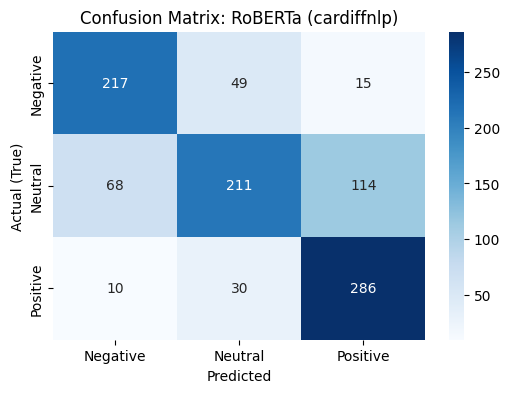


Model Evaluation Results: BERTweet (finiteautomata)
Accuracy:  0.7130
Precision: 0.7230 (Weighted)
Recall:    0.7130 (Weighted)
F1 Score:  0.7044 (Weighted)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.69      0.79      0.74       281
     Neutral       0.77      0.52      0.62       393
    Positive       0.69      0.87      0.77       326

    accuracy                           0.71      1000
   macro avg       0.72      0.73      0.71      1000
weighted avg       0.72      0.71      0.70      1000



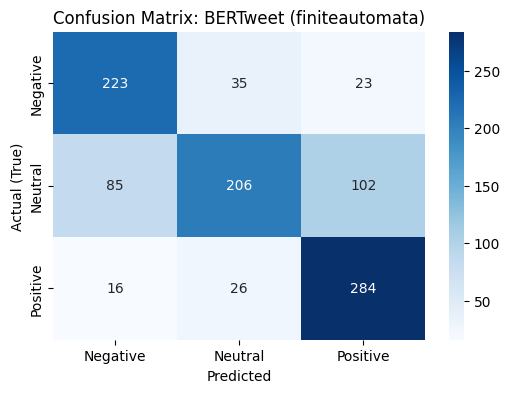


Model Evaluation Results: RoBERTa-large (j-hartmann)
Accuracy:  0.7070
Precision: 0.7074 (Weighted)
Recall:    0.7070 (Weighted)
F1 Score:  0.7045 (Weighted)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.69      0.79      0.74       281
     Neutral       0.71      0.60      0.65       393
    Positive       0.73      0.76      0.74       326

    accuracy                           0.71      1000
   macro avg       0.71      0.72      0.71      1000
weighted avg       0.71      0.71      0.70      1000



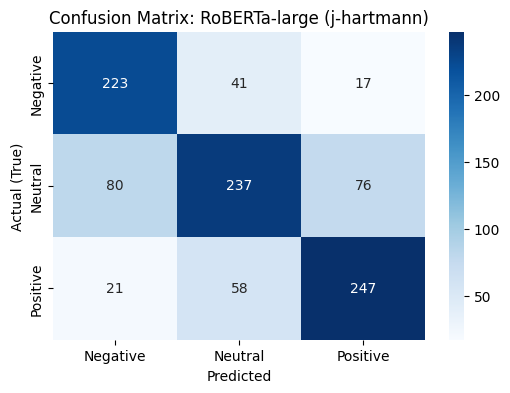

In [ ]:
# Evaluate results and plot Confusion Matrix
def evaluate_and_plot(true_labels, pred_labels, model_name):
    print(f"\n{'='*50}")
    print(f"Model Evaluation Results: {model_name}")
    print(f"{'='*50}")

    # Calculate Metrics
    acc = accuracy_score(true_labels, pred_labels)
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, pred_labels, average='weighted', zero_division=0)

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f} (Weighted)")
    print(f"Recall:    {recall:.4f} (Weighted)")
    print(f"F1 Score:  {f1:.4f} (Weighted)")

    print("\nClassification Report:")
    print(classification_report(true_labels, pred_labels, target_names=['Negative', 'Neutral', 'Positive'], zero_division=0))

    # Plot Confusion Matrix
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Neutral', 'Positive'],
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual (True)')
    plt.show()

# Call the evaluation function for each model
evaluate_and_plot(df['true_label'], df['roberta_pred'], "RoBERTa (cardiffnlp)")
evaluate_and_plot(df['true_label'], df['bert_pred'], "BERTweet (finiteautomata)")
evaluate_and_plot(df['true_label'], df['roberta_large_pred'], "RoBERTa-large (j-hartmann)")

### Model Error Analysis



In [ ]:
def analyze_misclassifications(df, true_label_col, pred_label_col, model_name, text_column_name):
    print(f"\n{'='*50}")
    print(f"Model Error Analysis: {model_name}")
    print(f"{'='*50}")

    misclassified_df = df[df[true_label_col] != df[pred_label_col]]

    if misclassified_df.empty:
        print("No misclassifications in this dataset! (Excellent)")
        return

    # Mapping numbers back to labels for display
    label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

    print(f"Total number of misclassified texts: {len(misclassified_df)}\n")

    # Case 1: Actual Negative (0) but predicted Neutral (1) or Positive (2)
    neg_misclassified = misclassified_df[
        (misclassified_df[true_label_col] == 0) &
        (misclassified_df[pred_label_col].isin([1, 2]))
    ]
    if not neg_misclassified.empty:
        print("--- Actual: Negative (0), Predicted: Neutral (1) or Positive (2) ---")
        for i, row in neg_misclassified.head(3).iterrows(): # Show top 3 examples
            print(f"  [Text]: {row[text_column_name]}")
            print(f"  [Actual]: {label_map[row[true_label_col]]}, [Predicted]: {label_map[row[pred_label_col]]}\n")

    # Case 2: Actual Neutral (1) but predicted Negative (0) or Positive (2)
    neu_misclassified = misclassified_df[
        (misclassified_df[true_label_col] == 1) &
        (misclassified_df[pred_label_col].isin([0, 2]))
    ]
    if not neu_misclassified.empty:
        print("--- Actual: Neutral (1), Predicted: Negative (0) or Positive (2) ---")
        for i, row in neu_misclassified.head(3).iterrows(): # Show top 3 examples
            print(f"  [Text]: {row[text_column_name]}")
            print(f"  [Actual]: {label_map[row[true_label_col]]}, [Predicted]: {label_map[row[pred_label_col]]}\n")

    # Case 3: Actual Positive (2) but predicted Negative (0) or Neutral (1)
    pos_misclassified = misclassified_df[
        (misclassified_df[true_label_col] == 2) &
        (misclassified_df[pred_label_col].isin([0, 1]))
    ]
    if not pos_misclassified.empty:
        print("--- Actual: Positive (2), Predicted: Negative (0) or Neutral (1) ---")
        for i, row in pos_misclassified.head(3).iterrows(): # Show top 3 examples
            print(f"  [Text]: {row[text_column_name]}")
            print(f"  [Actual]: {label_map[row[true_label_col]]}, [Predicted]: {label_map[row[pred_label_col]]}\n")

# Call the function for each model
analyze_misclassifications(df, 'true_label', 'roberta_pred', "RoBERTa (cardiffnlp)", text_col)
analyze_misclassifications(df, 'true_label', 'bert_pred', "BERTweet (finiteautomata)", text_col)
analyze_misclassifications(df, 'true_label', 'roberta_large_pred', "RoBERTa-large (j-hartmann)", text_col)


Model Error Analysis: RoBERTa (cardiffnlp)
Total number of misclassified texts: 286

--- Actual: Negative (0), Predicted: Neutral (1) or Positive (2) ---
  [Text]: I wish I had company
  [Actual]: Negative, [Predicted]: Neutral

  [Text]:  i`m on my mobile so it won`t let me  but i can`t stop thinking about you ;)x
  [Actual]: Negative, [Predicted]: Positive

  [Text]: Intel gfx driver situation much better with recent upgrades. kernel 2.6.30rc4 and driver from git: Suspend working again, fewer mem leaks
  [Actual]: Negative, [Predicted]: Positive

--- Actual: Neutral (1), Predicted: Negative (0) or Positive (2) ---
  [Text]: Clive it`s my birthday pat me  http://apps.facebook.com/dogbook/profile/view/6386106
  [Actual]: Neutral, [Predicted]: Positive

  [Text]:  well, the customer is always right (at least that`s what they tell me)
  [Actual]: Neutral, [Predicted]: Positive

  [Text]: Massive morning.. I`m stuffed now
  [Actual]: Neutral, [Predicted]: Negative

--- Actual: Positive (

### Analysis with New Dataset -> abdelmalekeladjelet/sentiment-analysis-dataset



In [ ]:
print("\n===== Downloading New Dataset =====")
new_dataset_path = kagglehub.dataset_download("abdelmalekeladjelet/sentiment-analysis-dataset")
print("New Dataset download complete! File location:", new_dataset_path)


===== Downloading New Dataset =====


100%|██████████| 8.68M/8.68M [00:00<00:00, 141MB/s]

Extracting files...


New Dataset download complete! File location: /root/.cache/kagglehub/datasets/abdelmalekeladjelet/sentiment-analysis-dataset/versions/1


In [ ]:
csv_files_new = [f for f in os.listdir(new_dataset_path) if f.endswith('.csv')]
if not csv_files_new:
    raise FileNotFoundError("No CSV files found in this new dataset.")

data_path_new = os.path.join(new_dataset_path, csv_files_new[0])
try:
    df_new = pd.read_csv(data_path_new)
except UnicodeDecodeError:
    df_new = pd.read_csv(data_path_new, encoding='latin-1')

print(f"New dataset loaded successfully. Total rows: {len(df_new)}")
print("Sample columns in the new dataset:", df_new.columns.tolist())

# Explicitly define column names for the new dataset
new_text_col = 'Comment'
new_sentiment_col = 'Sentiment'

# Check if these columns exist in the new DataFrame
if new_text_col not in df_new.columns:
    raise ValueError(f"Text column '{new_text_col}' not found in the new dataset")
if new_sentiment_col not in df_new.columns:
    raise ValueError(f"Sentiment column '{new_sentiment_col}' not found in the new dataset")

# Drop missing values and sample 1,000 rows for faster testing
df_new = df_new.dropna(subset=[new_text_col, new_sentiment_col])
if len(df_new) > 1000:
    df_new = df_new.sample(n=1000, random_state=42)
else:
    print(f"New dataset has only {len(df_new)} rows, no sampling performed.")


# Encode sentiment labels to numerical values (0=Negative, 1=Neutral, 2=Positive)
df_new['true_label'] = df_new[new_sentiment_col].apply(encode_true_label)
print("Sample of the new dataset after preparation:")
display(df_new.head())

New dataset loaded successfully. Total rows: 241145
Sample columns in the new dataset: ['Unnamed: 0', 'Comment', 'Sentiment']
Sample of the new dataset after preparation:


,Unnamed: 0,Comment,Sentiment,true_label
138371,139149,indian giving message country going ahead new ...,2,2
93134,93912,hating modi trend loom replies instant famous,2,2
99587,100365,hahaha modi khauff stronger sibling rivalries,2,2
167512,168290,watch official trailer modi subscribe erosnow ...,1,1
82026,82804,called concern poor modi bjp doesnt poor count...,0,0


In [ ]:
print("\n===== Inferring with all three models on the new dataset =====")
texts_new = df_new[new_text_col].astype(str).tolist()

print("Inferring with RoBERTa (cardiffnlp) on the new dataset...")
roberta_preds_new = roberta_pipe(texts_new, batch_size=32, truncation=True, max_length=512)
df_new['roberta_pred'] = [map_cardiffnlp_output(p) for p in roberta_preds_new]

print("Inferring with BERTweet (finiteautomata) on the new dataset...")
bert_preds_new = bert_pipe(texts_new, batch_size=32, truncation=True, max_length=512)
df_new['bert_pred'] = [map_bert_output(p) for p in bert_preds_new]

print("Inferring with RoBERTa-large (j-hartmann) on the new dataset...")
roberta_large_preds_new = roberta_large_pipe(texts_new, batch_size=32, truncation=True, max_length=512)
df_new['roberta_large_pred'] = [map_jhartmann_output(p) for p in roberta_large_preds_new]


===== Inferring with all three models on the new dataset =====
Inferring with RoBERTa (cardiffnlp) on the new dataset...
Inferring with BERTweet (finiteautomata) on the new dataset...
Inferring with RoBERTa-large (j-hartmann) on the new dataset...


### Model Evaluation Results on the New Dataset


Model Evaluation Results: RoBERTa (cardiffnlp) - New Dataset
Accuracy:  0.5530
Precision: 0.6236 (Weighted)
Recall:    0.5530 (Weighted)
F1 Score:  0.5481 (Weighted)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.48      0.55      0.51       219
     Neutral       0.49      0.75      0.59       349
    Positive       0.81      0.40      0.53       432

    accuracy                           0.55      1000
   macro avg       0.59      0.56      0.54      1000
weighted avg       0.62      0.55      0.55      1000



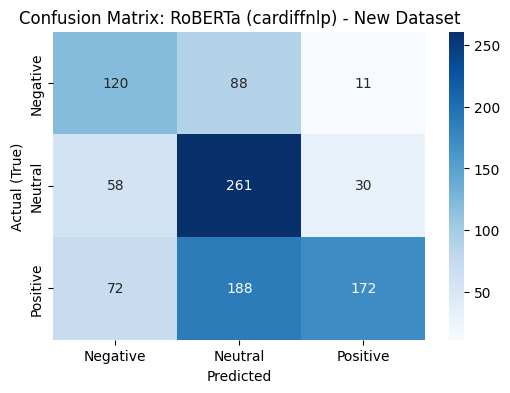


Model Evaluation Results: BERTweet (finiteautomata) - New Dataset
Accuracy:  0.5790
Precision: 0.6296 (Weighted)
Recall:    0.5790 (Weighted)
F1 Score:  0.5796 (Weighted)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.48      0.63      0.54       219
     Neutral       0.53      0.69      0.60       349
    Positive       0.79      0.46      0.58       432

    accuracy                           0.58      1000
   macro avg       0.60      0.59      0.57      1000
weighted avg       0.63      0.58      0.58      1000



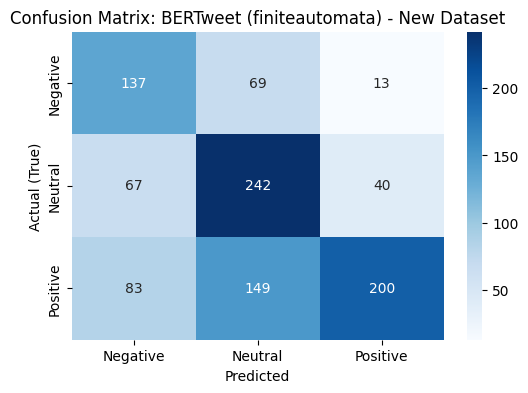


Model Evaluation Results: RoBERTa-large (j-hartmann) - New Dataset
Accuracy:  0.5220
Precision: 0.6201 (Weighted)
Recall:    0.5220 (Weighted)
F1 Score:  0.5111 (Weighted)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.44      0.55      0.49       219
     Neutral       0.47      0.74      0.57       349
    Positive       0.84      0.33      0.47       432

    accuracy                           0.52      1000
   macro avg       0.58      0.54      0.51      1000
weighted avg       0.62      0.52      0.51      1000



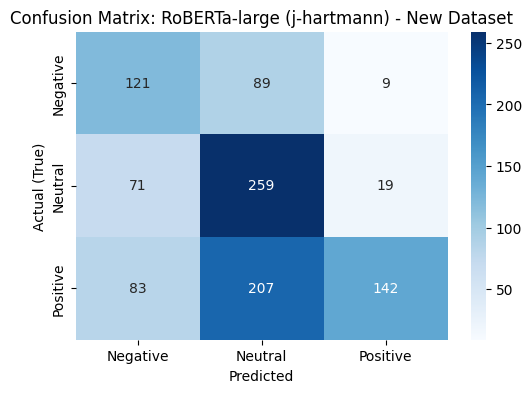

In [ ]:
# Call the evaluate_and_plot function with the new dataset
evaluate_and_plot(df_new['true_label'], df_new['roberta_pred'], "RoBERTa (cardiffnlp) - New Dataset")
evaluate_and_plot(df_new['true_label'], df_new['bert_pred'], "BERTweet (finiteautomata) - New Dataset")
evaluate_and_plot(df_new['true_label'], df_new['roberta_large_pred'], "RoBERTa-large (j-hartmann) - New Dataset")

### Model Error Analysis on the New Dataset

In [ ]:
# Call the analyze_misclassifications function with the new dataset
analyze_misclassifications(df_new, 'true_label', 'roberta_pred', "RoBERTa (cardiffnlp) - New Dataset", new_text_col)
analyze_misclassifications(df_new, 'true_label', 'bert_pred', "BERTweet (finiteautomata) - New Dataset", new_text_col)
analyze_misclassifications(df_new, 'true_label', 'roberta_large_pred', "RoBERTa-large (j-hartmann) - New Dataset", new_text_col)


Model Error Analysis: RoBERTa (cardiffnlp) - New Dataset
Total number of misclassified texts: 447

--- Actual: Negative (0), Predicted: Neutral (1) or Positive (2) ---
  [Text]: india shoots satellite space modi hails major breakthrough says india registâ­ered name space power
  [Actual]: Negative, [Predicted]: Positive

  [Text]: serious answer trump potus thennor modi saved country witnessing shameless spectacle head state gloating triumph generations scientistsleaders quietlydedicatedly went missions
  [Actual]: Negative, [Predicted]: Neutral

  [Text]: swami type economists job hand defend grandiose schemes modi gormint run anything opposition suggests
  [Actual]: Negative, [Predicted]: Neutral

--- Actual: Neutral (1), Predicted: Negative (0) or Positive (2) ---
  [Text]: disagree theres bigger fraud indian democracy modi
  [Actual]: Neutral, [Predicted]: Negative

  [Text]: ha im ready cant believe balls call haha wtf
  [Actual]: Neutral, [Predicted]: Negative

  [Text]: far nic

### Ensemble Prediction



Ensemble predictions generated for the original dataset.

Model Evaluation Results: Ensemble Model - Original Dataset
Accuracy:  0.7260
Precision: 0.7298 (Weighted)
Recall:    0.7260 (Weighted)
F1 Score:  0.7195 (Weighted)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.72      0.79      0.75       281
     Neutral       0.75      0.56      0.64       393
    Positive       0.71      0.87      0.78       326

    accuracy                           0.73      1000
   macro avg       0.73      0.74      0.73      1000
weighted avg       0.73      0.73      0.72      1000



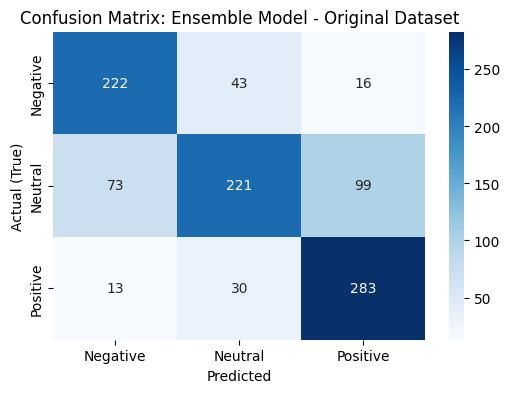

In [ ]:
# Function for ensemble prediction using majority voting
def ensemble_predictions(row):
    predictions = [row['roberta_pred'], row['bert_pred'], row['roberta_large_pred']]
    # Count occurrences of each prediction
    counts = pd.Series(predictions).value_counts()

    if len(counts) == 1:
        return counts.index[0] # All models agree
    elif len(counts) == 3 or (len(counts) == 2 and counts.max() == 1): # All three unique or a tie with two unique labels and equal counts
        # Tie-breaking rule: prefer Neutral (1), then Positive (2), then Negative (0)
        if 1 in predictions: return 1
        elif 2 in predictions: return 2
        else: return 0
    else: # Clear majority
        return counts.idxmax()

# Apply ensemble to original dataset
df['ensemble_pred'] = df.apply(ensemble_predictions, axis=1)
print("Ensemble predictions generated for the original dataset.")

# Evaluate ensemble on original dataset
evaluate_and_plot(df['true_label'], df['ensemble_pred'], "Ensemble Model - Original Dataset")

Ensemble predictions generated for the new dataset.

Model Evaluation Results: Ensemble Model - New Dataset
Accuracy:  0.5650
Precision: 0.6385 (Weighted)
Recall:    0.5650 (Weighted)
F1 Score:  0.5605 (Weighted)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.48      0.58      0.53       219
     Neutral       0.50      0.75      0.60       349
    Positive       0.83      0.41      0.54       432

    accuracy                           0.56      1000
   macro avg       0.60      0.58      0.56      1000
weighted avg       0.64      0.56      0.56      1000



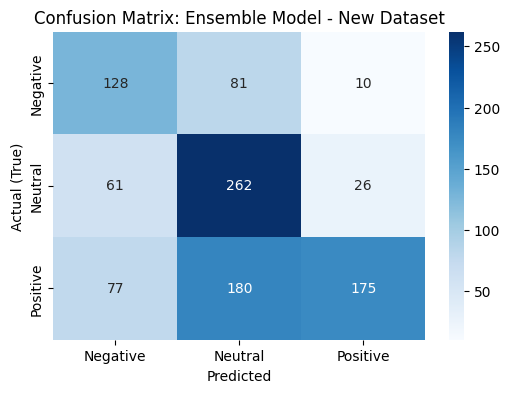

In [ ]:
# Apply ensemble to new dataset
df_new['ensemble_pred'] = df_new.apply(ensemble_predictions, axis=1)
print("Ensemble predictions generated for the new dataset.")

# Evaluate ensemble on new dataset
evaluate_and_plot(df_new['true_label'], df_new['ensemble_pred'], "Ensemble Model - New Dataset")

### Updating Model Comparison Summary with Ensemble Results

In [ ]:
# Collect metrics for Ensemble Model on original dataset
acc, precision, recall, f1 = get_metrics(df['true_label'], df['ensemble_pred'])
summary_metrics['Model'].append('Ensemble Model')
summary_metrics['Dataset'].append('Original')
summary_metrics['Accuracy'].append(acc)
summary_metrics['Precision'].append(precision)
summary_metrics['Recall'].append(recall)
summary_metrics['F1 Score'].append(f1)

# Collect metrics for Ensemble Model on new dataset
acc, precision, recall, f1 = get_metrics(df_new['true_label'], df_new['ensemble_pred'])
summary_metrics['Model'].append('Ensemble Model')
summary_metrics['Dataset'].append('New Dataset')
summary_metrics['Accuracy'].append(acc)
summary_metrics['Precision'].append(precision)
summary_metrics['Recall'].append(recall)
summary_metrics['F1 Score'].append(f1)

# Recreate and display the updated summary DataFrame
summary_df = pd.DataFrame(summary_metrics)
display(summary_df.round(4))

,Model,Dataset,Accuracy,Precision,Recall,F1 Score
0,RoBERTa (cardiffnlp),Original,0.714,0.7173,0.714,0.7062
1,BERTweet (finiteautomata),Original,0.713,0.7230,0.713,0.7044
2,RoBERTa-large (j-hartmann),Original,0.707,0.7074,0.707,0.7045
3,RoBERTa (cardiffnlp),New Dataset,0.553,0.6236,0.553,0.5481
4,BERTweet (finiteautomata),New Dataset,0.579,0.6296,0.579,0.5796
5,RoBERTa-large (j-hartmann),New Dataset,0.522,0.6201,0.522,0.5111
6,Ensemble Model,Original,0.726,0.7298,0.726,0.7195
7,Ensemble Model,New Dataset,0.565,0.6385,0.565,0.5605


### Model Comparison Summary Across Both Datasets



In [ ]:
summary_metrics = {
    'Model': [],
    'Dataset': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': []
}

# Helper function to get metrics without plotting
def get_metrics(true_labels, pred_labels):
    acc = accuracy_score(true_labels, pred_labels)
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, pred_labels, average='weighted', zero_division=0)
    return acc, precision, recall, f1

# Collect metrics for RoBERTa (cardiffnlp) on original dataset
acc, precision, recall, f1 = get_metrics(df['true_label'], df['roberta_pred'])
summary_metrics['Model'].append('RoBERTa (cardiffnlp)')
summary_metrics['Dataset'].append('Original')
summary_metrics['Accuracy'].append(acc)
summary_metrics['Precision'].append(precision)
summary_metrics['Recall'].append(recall)
summary_metrics['F1 Score'].append(f1)

# Collect metrics for BERTweet (finiteautomata) on original dataset
acc, precision, recall, f1 = get_metrics(df['true_label'], df['bert_pred'])
summary_metrics['Model'].append('BERTweet (finiteautomata)')
summary_metrics['Dataset'].append('Original')
summary_metrics['Accuracy'].append(acc)
summary_metrics['Precision'].append(precision)
summary_metrics['Recall'].append(recall)
summary_metrics['F1 Score'].append(f1)

# Collect metrics for RoBERTa-large (j-hartmann) on original dataset
acc, precision, recall, f1 = get_metrics(df['true_label'], df['roberta_large_pred'])
summary_metrics['Model'].append('RoBERTa-large (j-hartmann)')
summary_metrics['Dataset'].append('Original')
summary_metrics['Accuracy'].append(acc)
summary_metrics['Precision'].append(precision)
summary_metrics['Recall'].append(recall)
summary_metrics['F1 Score'].append(f1)

# Collect metrics for RoBERTa (cardiffnlp) on new dataset
acc, precision, recall, f1 = get_metrics(df_new['true_label'], df_new['roberta_pred'])
summary_metrics['Model'].append('RoBERTa (cardiffnlp)')
summary_metrics['Dataset'].append('New Dataset')
summary_metrics['Accuracy'].append(acc)
summary_metrics['Precision'].append(precision)
summary_metrics['Recall'].append(recall)
summary_metrics['F1 Score'].append(f1)

# Collect metrics for BERTweet (finiteautomata) on new dataset
acc, precision, recall, f1 = get_metrics(df_new['true_label'], df_new['bert_pred'])
summary_metrics['Model'].append('BERTweet (finiteautomata)')
summary_metrics['Dataset'].append('New Dataset')
summary_metrics['Accuracy'].append(acc)
summary_metrics['Precision'].append(precision)
summary_metrics['Recall'].append(recall)
summary_metrics['F1 Score'].append(f1)

# Collect metrics for RoBERTa-large (j-hartmann) on new dataset
acc, precision, recall, f1 = get_metrics(df_new['true_label'], df_new['roberta_large_pred'])
summary_metrics['Model'].append('RoBERTa-large (j-hartmann)')
summary_metrics['Dataset'].append('New Dataset')
summary_metrics['Accuracy'].append(acc)
summary_metrics['Precision'].append(precision)
summary_metrics['Recall'].append(recall)
summary_metrics['F1 Score'].append(f1)

summary_df = pd.DataFrame(summary_metrics)
display(summary_df.round(4))

,Model,Dataset,Accuracy,Precision,Recall,F1 Score
0,RoBERTa (cardiffnlp),Original,0.714,0.7173,0.714,0.7062
1,BERTweet (finiteautomata),Original,0.713,0.7230,0.713,0.7044
2,RoBERTa-large (j-hartmann),Original,0.707,0.7074,0.707,0.7045
3,RoBERTa (cardiffnlp),New Dataset,0.553,0.6236,0.553,0.5481
4,BERTweet (finiteautomata),New Dataset,0.579,0.6296,0.579,0.5796
5,RoBERTa-large (j-hartmann),New Dataset,0.522,0.6201,0.522,0.5111
